# Linear Ordinary Differential Equations

## Classification of ODEs

Differential equations are equations that relate a function to its derivatives, arising naturally whenever we model systems where rates of change depend on current states. In mechanical engineering, we encounter them when analyzing how temperatures evolve in time, how structures deform under loads, or how mechanical systems move under applied forces. A differential equation is called **ordinary** (an ODE) when it involves a function of a single independent variable and its derivatives with respect to that variable. For instance, Newton's Law of Cooling describes how temperature $T(t)$ changes with time $t$ through the equation $\frac{dT}{dt} = -k(T - T_{env})$, making it an ODE since $T$ depends only on the single variable $t$.


We distinguish between **linear** and **nonlinear** ODEs based on how the unknown function and its derivatives appear in the equation. A linear ODE has the form where the unknown function and all its derivatives appear to the first power and are not multiplied together, such as $\frac{d^2x}{dt^2} + c\frac{dx}{dt} + kx = f(t)$. In contrast, a nonlinear ODE contains terms like $x^2$, $\sin(x)$, or products of derivatives such as $x\frac{dx}{dt}$. Linear ODEs are particularly valuable because they admit powerful solution techniques: superposition applies, analytical solutions often exist in closed form, and numerical methods behave predictably. The linearity allows us to use SymPy's `dsolve` function to obtain exact symbolic solutions, which is the focus of this chapter.


Nonlinear ODEs, while more challenging, appear frequently in realistic engineering models where effects like rigid body rotation, friction, quadratic damping, or material nonlinearity cannot be ignored. We shall address techniques for nonlinear ODEs in subsequent chapters, where numerical methods become essential since closed-form solutions rarely exist. Beyond ordinary differential equations lie **partial differential equations** (PDEs), which involve functions of multiple independent variables and their partial derivatives. The heat equation $\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$, describing temperature $u(x,t)$ varying in both space $x$ and time $t$, exemplifies a PDE. While PDEs govern many phenomena in continuum mechanics (such as heat conduction in bodies, stress distributions in structures, and fluid flow), they demand fundamentally different solution approaches, particularly the Finite Element Method. For a comprehensive treatment of PDEs and finite element techniques, we refer readers to specialized courses in that domain (ask the author about such courses for recommendations).


In this chapter we focus on linear ordinary differential equations that possess closed-form solutions obtainable through SymPy's symbolic solver. We examine initial value problems, where conditions are specified at a single point in time, and boundary value problems, where conditions apply at multiple locations. Through examples drawn from thermal analysis, dynamics, and structural mechanics, we demonstrate how differential equations translate physical laws into mathematical form and how symbolic computation provides exact solutions that reveal system behavior.

## Newton's Law of Cooling - Initial value problem

Newton's Law of Cooling describes the rate at which an object cools or heats in relation to the temperature of its surroundings. The differential equation is given by:

$$\frac{dT}{dt} = -k(T - T_{env})$$

where $T$ is the temperature of the object, $T_{env}$ is the ambient temperature, $k$ is a positive constant that depends on the characteristics of the object and its surroundings, $t$ is time.    

We solve this differential equation using sympy's `dsolve` function:


In [1]:
#| echo: false
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import mechanicskit as mk

%config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.family": "serif",      # Use serif fonts for text
    "mathtext.fontset": "cm",    # 'cm' stands for Computer Modern (Standard LaTeX font)
})


For differential equations in sympy we first need to declare the variables and functions we will be using. In this case we have the temperature $T$ as a function of time $t$. Then the differential is created using the `diff` method of the `sp.Function` object `T`. The differential equation is formed by the `sp.Eq` function, which takes the left-hand side and right-hand side of the equation as arguments.


In [2]:
#| code-fold: false
t = sp.symbols('t', real=True)
T = sp.Function('T')(t)
k, T_env = sp.symbols('k T_env', real=True)

DE = sp.Eq(T.diff(t,1), -k*(T-T_env))
DE

Eq(Derivative(T(t), t), -k*(-T_env + T(t)))

Depending on the order of the differential equation we need to provide initial conditions or boundary conditions to get a unique solution. In this case we will provide an initial condition for the temperature at time $t=0$. We define a variable `IV` to hold the inital value as a dictionary. The key is the function evaluated at the initial time and the value is the initial temperature.

In [3]:
#| code-fold: false
IV = {T.subs(t,0): 95}
IV

{T(0): 95}

Then we call the `sp.dsolve` function with the differential equation and the initial conditions as arguments. The solution is returned as an equation, which we can print out. Here we extract the right-hand side of the equation to get the temperature as a function of time.



In [4]:
#| code-fold: false
T_sol = sp.dsolve(DE, ics=IV).rhs
T_sol

T_env + (95 - T_env)*exp(-k*t)

Next we substitute some values for the constants such that we have an expression that depends only on one variable. 

In [5]:
#| code-fold: false
T = T_sol.subs({k:0.1, T_env:20})
T

20 + 75*exp(-0.1*t)

Then we simply plot using the mechanicskit plotting function `mk.fplot`.

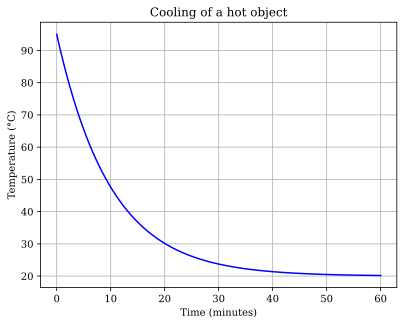

In [6]:
#| code-fold: true
#| classes: size-80
mk.fplot(T, (t, 0, 60), 
         color='blue',
         title="Cooling of a hot object", 
         xlabel="Time (minutes)", 
         ylabel="Temperature (°C)")
plt.gca().grid(True)

The solution exhibits exponential decay, as expected for a first-order linear ODE with constant coefficients. The object initially at 95°C cools toward the ambient temperature of 20°C, with the temperature difference $(T - T_{env})$ decreasing exponentially at a rate determined by the cooling constant $k = 0.1$ $\text{min}^{-1}$. Observe that the temperature approaches the ambient value asymptotically. This theoretically requires infinite time to reach exact equilibrium, though it practically becomes indistinguishable from $T_{env}$ after several decay time constants, where $	au = 1/k = 10$ minutes. The negative sign in the differential equation ensures that when $T > T_{env}$, the derivative $dT/dt$ is negative (cooling), while if $T < T_{env}$, the object would warm. This physical consistency between mathematical signs and thermal behavior exemplifies how differential equations encode physical laws.

## Projectile Motion 

Projectile motion describes the motion of an object that is thrown or projected into the air, subject to only the acceleration of gravity. The differential equations governing projectile motion are given by:

$$
\begin{align*}
\frac{d^{2}x}{dt^{2}} & =0\\
\frac{d^{2}y}{dt^{2}} & =-g
\end{align*}
$$

with $x$ and $y$ being the horizontal and vertical positions of the object, respectively, $g$ is the acceleration due to gravity, and $t$ is time. The initial conditions are given by the initial position and velocity of the object, e.g., $x(0) = x_0$, $y(0) = y_0$, $\frac{dx}{dt}(0) = v_{x0} = v_0 \cos \theta$, and $\frac{dy}{dt}(0) = v_{y0} = v_0 \sin\theta$.

This here is a system of second-order ordinary differential equations. Sympy's `dsolve` function handles this naturally, we just need to provide the equations and the initial conditions as a list of equations, and sympy will return the solutions for both $x(t)$ and $y(t)$.

In [7]:
#| code-fold: false
import sympy as sp
t = sp.symbols('t', real=True, positive=True)
x = sp.Function('x')(t)
y = sp.Function('y')(t)
g = sp.symbols('g', real=True, positive=True)
v_0, theta = sp.symbols('v_0 theta', real=True)

DE = [sp.Eq(x.diff(t,2), 0),
      sp.Eq(y.diff(t,2), -g)]

In [8]:
#|echo: false
DE[0]

Eq(Derivative(x(t), (t, 2)), 0)

In [9]:
#|echo: false
DE[1]

Eq(Derivative(y(t), (t, 2)), -g)

In [10]:
#| code-fold: false
IV = {x.subs(t,0): 0,
      x.diff(t,1).subs(t,0): v_0*sp.cos(theta),
      y.subs(t,0): 0,
      y.diff(t,1).subs(t,0): v_0*sp.sin(theta)}
IV

{x(0): 0,
 Subs(Derivative(x(t), t), t, 0): v_0*cos(theta),
 y(0): 0,
 Subs(Derivative(y(t), t), t, 0): v_0*sin(theta)}

In [11]:
#| code-fold: false
sol = sp.dsolve(DE, ics=IV)

In [12]:
#|echo: false
sol[0]

Eq(x(t), t*v_0*cos(theta))

In [13]:
#|echo: false
sol[1]

Eq(y(t), -g*t**2/2 + t*v_0*sin(theta))

These solutions reveal the independence of horizontal and vertical motion under gravity alone. The horizontal position $x(t) = tv_0\cos\theta$ increases linearly with time since no horizontal forces act on the projectile, while the vertical position $y(t) = tv_0\sin\theta - \frac{1}{2}gt^2$ combines linear growth from the initial upward velocity with quadratic decay due to gravitational acceleration. The system of two second-order ODEs decouples completely because the differential equations contain no cross-coupling terms; the acceleration in each direction depends only on forces in that direction. By eliminating time between the two equations, we obtain the trajectory $y = x\tan\theta - \frac{gx^2}{2v_0^2\cos^2\theta}$, which is a parabola as expected. The maximum height occurs when $\frac{dy}{dt} = 0$, giving $t = \frac{v_0\sin\theta}{g}$, while the range (horizontal distance at $y = 0$) is $R = \frac{v_0^2\sin(2\theta)}{g}$, maximized at $\theta = 45°$ for level ground launch and landing.

Note that air resistance is neglected in this idealized model. Including drag forces would couple the horizontal and vertical motions, leading to nonlinear ODEs that require numerical methods for solution. However, the linear ODEs presented here capture the essential physics of projectile motion under gravity alone, providing closed-form expressions for position as functions of time.

## Oscillating slider

![](graphics/OscillatingSlider.png)

A spring mounted slider is being moved along the $x$-axis and has an initial velocity $v_0=2$ m/s in the s -direction as it crosses the mid-position where $s=0$ and $t=0$. The two springs together exert a retarding force to the motion of the slider, which gives it an acceleration proportional to the displacement but oppositely directed and equal to $\frac{d^2}{dt^2}s=-k^2 s$, where $k=4$. Determine the displacement of the slider and plot it over time.

In [14]:
#| code-fold: false
t = sp.symbols('t', real=True, positive=True)
s = sp.Function('s')(t)
k = sp.symbols('k', real=True, positive=True)
v_0 = sp.symbols('v_0', real=True)

DE = sp.Eq(s.diff(t,2), -k**2 * s)
DE

Eq(Derivative(s(t), (t, 2)), -k**2*s(t))

In [15]:
#| code-fold: false
IV = {s.subs(t,0): 0, s.diff(t,1).subs(t,0): v_0}
IV

{s(0): 0, Subs(Derivative(s(t), t), t, 0): v_0}

In [16]:
#| code-fold: false
s_e = sp.dsolve(DE, ics=IV).rhs
s_e

v_0*sin(k*t)/k

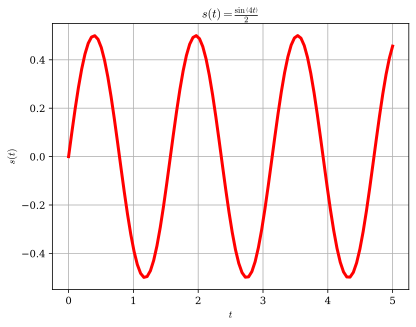

In [17]:
#| code-fold: true
#| classes: size-80
fun = s_e.subs({k:4, v_0:2})
mk.fplot(fun, (t, 0, 5),
         color='red', xlabel='$t$', ylabel='$s(t)$', lw=3,
         title=f'$s(t)={sp.latex(fun)}$')
plt.gca().grid(True)

The solution $s(t) = \frac{v_0}{k}\sin(kt) = 0.5\sin(4t)$ demonstrates simple harmonic motion, where the slider oscillates sinusoidally with angular frequency $\omega = k = 4$ rad/s and amplitude $A = v_0/k = 0.5$ m. The period of oscillation is $T = 2\pi/k \approx 1.57$ s, during which the slider completes one full cycle from the origin, reaching maximum displacement, returning through the origin to minimum displacement, and back. Since no damping or external forcing acts on the system, the motion is purely conservative—total mechanical energy (kinetic plus potential) remains constant, and oscillations continue indefinitely with unchanging amplitude. The initial condition $s(0) = 0$ with $\dot{s}(0) = v_0$ determines that the motion follows a sine function rather than cosine, starting at the equilibrium position with maximum velocity.

We can introduce viscous damping to model more realistic behavior where energy dissipates over time. The differential equation for damped harmonic motion becomes

$$
\frac{d^2s}{dt^2} + c \frac{ds}{dt} + k^2 s = 0
$$

where $c > 0$ represents the damping coefficient proportional to velocity. This additional term extracts energy from the system, causing oscillation amplitude to decay exponentially while the frequency decreases slightly from the undamped natural frequency.

In [18]:
#| code-fold: false
t = sp.symbols('t', real=True, positive=True)
s = sp.Function('s')(t)
k, c = sp.symbols('k c', real=True, positive=True)
v_0 = sp.symbols('v_0', real=True)

DE = sp.Eq(s.diff(t,2) , -k**2 * s - c*s.diff(t,1))
DE

Eq(Derivative(s(t), (t, 2)), -c*Derivative(s(t), t) - k**2*s(t))

In [19]:
#| code-fold: false
IV = {s.subs(t,0): 0, s.diff(t,1).subs(t,0): v_0}
IV

{s(0): 0, Subs(Derivative(s(t), t), t, 0): v_0}

In [20]:
#| code-fold: false
s_e = sp.dsolve(DE, ics=IV).rhs
s_e

v_0*exp(t*(-c + sqrt(c - 2*k)*sqrt(c + 2*k))/2)/(sqrt(c - 2*k)*sqrt(c + 2*k)) - v_0*exp(-t*(c + sqrt(c - 2*k)*sqrt(c + 2*k))/2)/(sqrt(c - 2*k)*sqrt(c + 2*k))

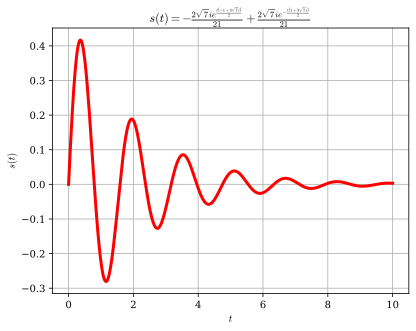

In [21]:
#| code-fold: true
#| classes: size-80
fun = s_e.subs({k:4, v_0:2, c:1})
mk.fplot(fun, (t, 0, 10), npoints=500,
         color='red', xlabel='$t$', ylabel='$s(t)$', lw=3,
         title=f'$s(t)={sp.latex(fun)}$')
plt.gca().grid(True)

The damped solution exhibits oscillations with exponentially decaying amplitude, characteristic of **underdamped** motion when $c < 2k$ (in our case, $c = 1 < 2(4) = 8$). The symbolic solution from SymPy appears in exponential form involving complex-valued expressions, but we can rewrite it in terms of real trigonometric functions. The general solution has the form $s(t) = Ae^{-\zeta\omega_n t}\sin(\omega_d t + \phi)$, where $\zeta = c/(2k)$ is the damping ratio, $\omega_n = k$ is the natural frequency, and $\omega_d = \omega_n\sqrt{1-\zeta^2}$ is the damped frequency. The envelope $Ae^{-\zeta\omega_n t}$ decays exponentially, causing the oscillation amplitude to decrease over time as energy dissipates through damping.

Three regimes exist depending on the damping coefficient:
- **Underdamped** ($c < 2k$): Oscillatory motion with exponentially decaying amplitude, as shown
- **Critically damped** ($c = 2k$): Fastest return to equilibrium without oscillation
- **Overdamped** ($c > 2k$): Slow non-oscillatory return to equilibrium

Recall from complex analysis that Euler's formula $e^{i\theta} = \cos\theta + i\sin\theta$ connects exponential and trigonometric representations. The symbolic solution SymPy returns uses this exponential form with imaginary exponents, which when simplified yields the familiar sine and cosine functions describing oscillatory behavior.

We now examine how initial conditions affect the damped oscillator response by reversing the conditions: starting with an initial displacement $s(0) = 1$ m and zero initial velocity $\dot{s}(0) = 0$. This corresponds physically to pulling the slider to position $s = 1$ and releasing it from rest, rather than striking it at the equilibrium position. The solution will still exhibit underdamped oscillatory decay, but the phase relationship changes—the motion now begins with a cosine-like response rather than sine-like, reflecting the different starting configuration.

In [22]:
#| code-fold: false
IV = {s.subs(t,0): 1, s.diff(t,1).subs(t,0): 0}
IV

{s(0): 1, Subs(Derivative(s(t), t), t, 0): 0}

In [23]:
#| code-fold: false
s_e = sp.dsolve(DE, ics=IV).rhs
s_e

(-c/(2*sqrt(c - 2*k)*sqrt(c + 2*k)) + 1/2)*exp(-t*(c + sqrt(c - 2*k)*sqrt(c + 2*k))/2) + (c/(2*sqrt(c - 2*k)*sqrt(c + 2*k)) + 1/2)*exp(t*(-c + sqrt(c - 2*k)*sqrt(c + 2*k))/2)

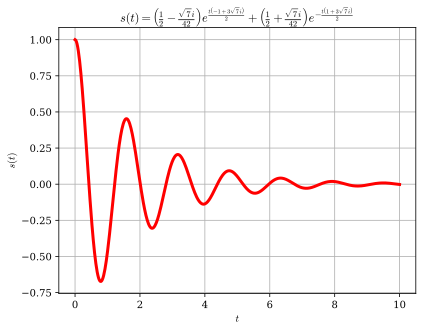

In [24]:
#| code-fold: true
#| classes: size-80
fun = s_e.subs({k:4, v_0:2, c:1})
mk.fplot(fun, (t, 0, 10), npoints=500,
         color='red', xlabel='$t$', ylabel='$s(t)$', lw=3,
         title=f'$s(t)={sp.latex(fun)}$')
plt.gca().grid(True)

The response with initial displacement shows the slider beginning at maximum displacement and immediately experiencing restoring force toward equilibrium, combined with damping resistance. Unlike the previous case where velocity was maximum at $t = 0$, here the slider starts from rest and accelerates toward equilibrium. Both solutions eventually decay to $s = 0$ at the same exponential rate determined by the damping ratio $\zeta = c/(2k)$, demonstrating that the decay envelope is a property of the system itself, independent of initial conditions. The initial conditions affect only the amplitude and phase of the oscillation within that envelope. This superposition property, where the general solution is a linear combination of responses to different initial conditions, is a hallmark of linear differential equations.

## The elliptic equation - Boundary value problem

We shall begin by considering a simple model problem, which nevertheless covers many different physical problems:

$$
-\frac{d}{dx} \left( k\frac{du}{dx} \right) = f(x),\quad x \in (0,L) \tag{1}
$$

together with the boundary conditions

$$
u(0) = u_0, \quad \frac{du}{dx}(L) = F. \tag{2}
$$

Some examples of physical problems that can be modeled by equations of the form (1) are:

- Steady-state heat conduction in a rod of length L with thermal conductivity $k>0$ and internal heat source $f(x)$. 
- Axial deformation of a bar of length $L$ with $k>0$ being the Young's modulus, distributed axial load $f(x)$, fixed at $x=0$ and subjected to an axial force $F$ at $x=L$. Furthermore, we have the $\frac{du}{dx}$ representing strain and $q=-k\frac{du}{dx}$ is the axial stress in the bar. The differential equation thus expresses the balance of forces in the bar.

This is a type of **second-order linear ordinary differential equation**. Second order because the highest derivative is of order two, linear because the unknown function $u$ and its derivatives appear to the first power and are not multiplied together and ordinary because there is only one independent variable $x$.

It is an elliptic equation because it describes a steady-state situation, where the solution does not change with time. It is specifically known as the Poisson equation if $k$ is constant and $f(x)$ is non-zero, and the Laplace equation if $f(x)=0$.

### Classification of boundary conditions

A unique solution to a second-order ordinary differential equation requires two boundary conditions. Some common types of boundary conditions are as follows:

Common types include the *Dirichlet boundary condition*, which specifies the value of the function at a boundary point (e.g., $u(0) = u_0$), and the *Neumann boundary condition*, which specifies the value of the derivative of the function at a boundary point (e.g., $\frac{du}{dx}(L) = F$). We can have two Dirichlet conditions, one at each boundary, but we cannot have two Neumann conditions, as this would lead to an infinite number of solutions differing by a constant.

**Physical interpretation of the boundary conditions**

| Field         | Variable $u$    | Parakmeter $k$       | Dirichlet BC               | Neumann BC                      |
|---------------|-----------------|--------------------- |----------------------------|---------------------------------|
| Heat Transfer | Temperature     | Thermal conductivity | Fixed temperature          | Prescribed heat flux            |
| Mechanics     | Displacement    | Young's modulus      | Fixed displacement         | Prescribed force                |

### Solving the BVP with sympy

In [25]:
#| code-fold: false
x = sp.symbols('x', real=True)
u= sp.Function('u')(x)
k, c, v, f = sp.symbols('k c v f', real=True)
F, L = sp.symbols('F L', real=True)

DE = sp.Eq(-u.diff(x,2)*k, f)
DE

Eq(-k*Derivative(u(x), (x, 2)), f)

In [26]:
#| code-fold: false
BV = {u.subs(x,0): 0, u.diff(x,1).subs(x,L): F}
BV

{u(0): 0, Derivative(u(L), L): F}

In [27]:
#| code-fold: false
u_e = sp.dsolve(DE, ics=BV).rhs
u_e

-f*x**2/(2*k) + x*(F*k + L*f)/k

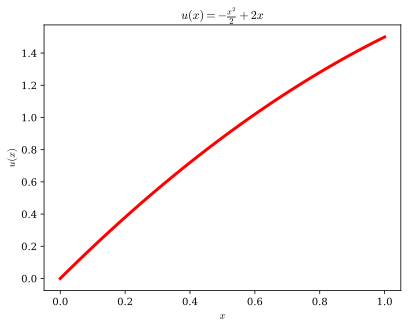

In [28]:
#| code-fold: true
#| classes: size-80
fun = u_e.subs({k:1, F:1, L:1, f:1})
mk.fplot(fun, (x, 0, 1),
         color='red', xlabel='$x$', ylabel='$u(x)$', lw=3,
         title=f'$u(x)={sp.latex(fun)}$')

The solution $u(x) = x - \frac{1}{2}x^2$ exhibits a parabolic profile, as expected for a second-order ODE with constant source term $f = 1$ and constant material property $k = 1$. The displacement is zero at the fixed boundary $x = 0$ (Dirichlet condition) and reaches maximum value at the free end $x = 1$ where the prescribed force $F = 1$ acts (Neumann condition). Physically, this represents a bar under uniform distributed load $f$ with one end fixed and the other subjected to an axial force. 

### The transport equation - Boundary value problem

We can have an extra term in the differential equation that represents transport or convection. The transport equation is given by:

$$
-\underbrace{\frac{d}{d x}\left(k \frac{d u}{d x}\right)}_{\text {Diffusion / Conduction }}  +  \underbrace{v \frac{d u}{d x}}_{\text {Transport / Advection }}   = \underbrace{f}_{\text {Source term }}
$$

Diffusion/conduction term: This term represents the diffusion or conduction of a quantity (like heat or mass) through a medium. The coefficient $k$ is the diffusion or conduction coefficient, which quantifies how easily the quantity spreads out.

Transport/advection term: This term represents the transport or advection of the quantity due to a velocity field $v$. It describes how the quantity is carried along by the flow of the medium.

Depending on the relative magnitude of the diffusion and transport terms, the solution behavior can vary significantly. When diffusion dominates, the solution tends to be smooth and gradual. However, when transport dominates, the solution can exhibit sharp gradients or layers, which are often referred to as boundary layers.

In [29]:
#| code-fold: false
DE = sp.Eq(-u.diff(x,2)*k + v*u.diff(x,1), f)
DE

Eq(-k*Derivative(u(x), (x, 2)) + v*Derivative(u(x), x), f)

In [30]:
#| code-fold: false
BV = {u.subs(x,0): 0, u.diff(x,1).subs(x,L): F}
BV

{u(0): 0, Derivative(u(L), L): F}

In [31]:
#| code-fold: false
u_e = sp.dsolve(DE, ics=BV).rhs
u_e

-F*k*exp(-L*v/k)/v + f*k*exp(-L*v/k)/v**2 + f*x/v + (F*k*exp(-L*v/k)/v - f*k*exp(-L*v/k)/v**2)*exp(v*x/k)

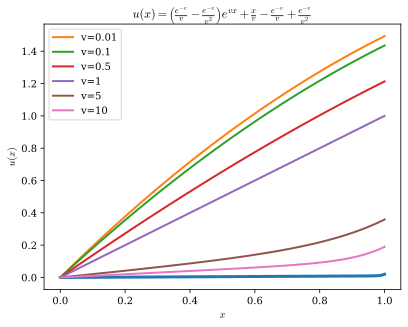

In [32]:
#| code-fold: true
#| classes: size-80
fun = u_e.subs({k:1, F:1, L:1, f:1, v:100})

mk.fplot(fun, (x, 0, 1), xlabel='$x$', ylabel='$u(x)$', lw=3,
         title=f'$u(x)={sp.latex(u_e.subs({k:1, F:1, L:1, f:1}))}$')

for v_val in [0.01, 0.1, 0.5, 1, 5, 10]:
    fun = u_e.subs({k:1, F:1, L:1, f:1, v:v_val})
    mk.fplot(fun, (x, 0, 1), lw=2, label=f'v={v_val}')

ax = plt.gca()
ax.legend()

The transport equation solution demonstrates dramatically different behavior depending on the Péclet number $Pe = vL/k$, which measures the relative importance of convection to diffusion. For small $v$ (low Péclet number), diffusion dominates and the solution varies smoothly across the domain, similar to the pure diffusion case. As $v$ increases, convection becomes more significant, and a boundary layer forms near $x = 1$. This is a thin region where the solution changes rapidly to satisfy the boundary condition. For $v = 100$, the solution remains nearly constant at the inlet value through most of the domain, then drops sharply near the outlet.

This boundary layer phenomenon has profound implications for numerical solution methods. Standard finite element discretizations with uniform mesh spacing fail to resolve steep gradients in the boundary layer, producing spurious oscillations. Practitioners must either use very fine meshes near boundaries (increasing computational cost) or employ specialized stabilization techniques. The behavior shown here, where smooth solutions for diffusion-dominated problems become layer-like as convection increases, appears throughout continuum mechanics in fluid flow (high Reynolds number), heat transfer (high Péclet number), and structural mechanics (thin shells and plates). Understanding when and where boundary layers form is essential for selecting appropriate solution methods.

### The Reaction-Diffusion equation

We can also have this type of equation:

$$
\underbrace{-\frac{d}{d x}\left(k \frac{d u}{d x}\right)}_{\text {Diffusion / Conduction }}+\underbrace{c u}_{\text {Reaction / Absorption }}=\underbrace{f}_{\text {Source / External Force }}
$$


Reaction/absorption term: This term represents a reaction or absorption process that affects the quantity $u$. The coefficient $c$ quantifies the rate of reaction or absorption. A positive value of $c$ indicates that the quantity is being absorbed or consumed, while a negative value indicates that it is being produced or generated.

| Field         | Interpretation of $cu$   | Physical Context     | 
|---------------|--------------------------|--------------------- |
| Heat Transfer | Newton's Law of Cooling  | A bar losing heat to the surrounding air ($c$ is the heat transfer coefficient). |
| Mechanics     | Elastic Foundation       | A beam or bar resting on an elastic "bed" (like a rail on gravel) that pushes back.      |

:::{.callout-note}
If $c>0$, the "reaction" term acts as a stabilizer (pulling $u$ towards zero), while if $c<0$, it acts as a destabilizer, the solution may grow without bound. For a pure Neumann problem, one can add a constant to $c$ to ensure $c>0$ and thus a unique solution.
:::

In [33]:
#| code-fold: false
DE = sp.Eq(-u.diff(x,2)*k + c*u, f)
DE

Eq(c*u(x) - k*Derivative(u(x), (x, 2)), f)

In [34]:
#| code-fold: false
# BV = {u.subs(x,0): 0, u.diff(x,1).subs(x,L): F}
BV = {u.subs(x,0): 0, u.diff(x,1).subs(x,L): F}
BV


{u(0): 0, Derivative(u(L), L): F}

In [35]:
#| code-fold: false
u_e = sp.dsolve(DE, ics=BV).rhs
u_e

(-F*c*exp(L*sqrt(c/k))/(c*sqrt(c/k)*exp(2*L*sqrt(c/k)) + c*sqrt(c/k)) - f*sqrt(c/k)*exp(2*L*sqrt(c/k))/(c*sqrt(c/k)*exp(2*L*sqrt(c/k)) + c*sqrt(c/k)))*exp(-x*sqrt(c/k)) + (F*c*exp(L*sqrt(c/k))/(c*sqrt(c/k)*exp(2*L*sqrt(c/k)) + c*sqrt(c/k)) - f*sqrt(c/k)/(c*sqrt(c/k)*exp(2*L*sqrt(c/k)) + c*sqrt(c/k)))*exp(x*sqrt(c/k)) + f/c

(exp(2*x + 1) - E)*exp(-x)/(1 + exp(2))

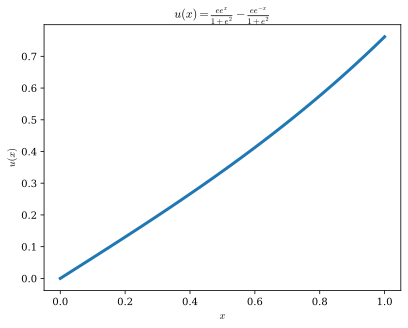

In [36]:
#| code-fold: true
#| classes: size-80
fun = u_e.subs({k:1, F:1, L:1, f:0, c:1})

mk.fplot(fun, (x, 0, 1), xlabel='$x$', ylabel='$u(x)$', lw=3,
         title=f'$u(x)={sp.latex(fun)}$')

fun.simplify()

The reaction-diffusion solution with $c = 1$, $k = 1$, $f = 0$, and applied force $F = 1$ exhibits exponential variation rather than the parabolic profile of pure diffusion. The solution grows from the fixed boundary $u(0) = 0$ toward the free end, with curvature determined by the competition between diffusion (which smooths gradients) and reaction (which removes the quantity proportionally to its local value). The characteristic length scale $\ell = \sqrt{k/c} = 1$ m determines how far effects propagate from boundaries before the reaction term dominates.

In the mechanical interpretation of a beam on an elastic foundation, the reaction term $cu$ represents the resistance from the supporting medium, where the foundation pushes back proportionally to the beam's displacement. Large $c$ means stiff foundation, causing the beam to deform only locally near applied loads. Small $c$ represents soft foundation, allowing deformation to spread over longer distances. The exponential decay of influence is characteristic of such problems: a load applied at one location affects nearby regions significantly but has exponentially diminishing influence farther away. This localized response contrasts sharply with beams without foundation support, where loads cause deformation extending over the entire span.

## The Euler-Bernoulli beam equation - Boundary value problem

An important fourth-order differential equation in mechanical engineering is the Euler-Bernoulli beam equation, which describes the relationship between the applied load on a beam and its resulting deflection. The equation is given by:

$$
-\frac{d^2}{dx^2} \left( EI \frac{d^2 w}{dx^2} \right) = q(x)
$$

where $w(x)$ is the deflection of the beam at position $x$, $E$ is the Young's modulus of the beam material, $I$ is the moment of inertia of the beam's cross-sectional area, and $q(x)$ is the distributed load applied to the beam.

The derivatives of $w(x)$ have physical interpretations under the small angle assumption:

The derivatives of $w(x)$ have direct physical interpretations under the small angle assumption. The first derivative, $\frac{dw}{dx}$, represents the slope of the beam, while the second derivative, $\frac{d^2w}{dx^2}$, represents its curvature and is related to the bending moment. The third derivative, $\frac{d^3w}{dx^3}$, is related to the shear force, and the fourth derivative, $\frac{d^4w}{dx^4}$, is related to the distributed load.

One needs four boundary conditions to solve a fourth-order differential equation. Common boundary conditions for beams include:

- **Simply supported beam**: The beam is supported at both ends, allowing rotation but not vertical displacement. The boundary conditions are $w(0) = 0$, $w(L) = 0$, $\frac{d^2 w}{dx^2}(0) = 0$, and $\frac{d^2 w}{dx^2}(L) = 0$.
- **Clamped beam**: The beam is fixed at both ends, preventing both rotation and vertical displacement. The boundary conditions are $w(0) = 0$, $w(L) = 0$, $\frac{dw}{dx}(0) = 0$, and $\frac{dw}{dx}(L) = 0$.
- **Cantilever beam**: The beam is fixed at one end and free at the other. The boundary conditions are $w(0) = 0$, $\frac{dw}{dx}(0) = \theta(0) = 0$, $\frac{d^2 w}{dx^2}(L) = M(L) = 0$, and $\frac{d^3 w}{dx^3}(L) = T(L) = 0$.

where $L$ is the length of the beam, $\theta$ the slope, $M$ the bending moment and $T$ the shear force.

We can solve the Euler-Bernoulli beam equation using sympy's `dsolve` function, providing the differential equation and the appropriate boundary conditions. The solution will give us the deflection of the beam as a function of position along its length.


In [37]:
#| code-fold: false
import sympy as sp
x = sp.symbols('x')
w = sp.Function('w')(x)
E, I, L, theta, T, q_0, F = sp.symbols('E I L theta T q_0, F', real=True)
q = sp.Function('q')(x)

In [38]:
DE = sp.Eq(-sp.diff(E*I*sp.diff(w, x, 2), x, 2), q)
DE

Eq(-E*I*Derivative(w(x), (x, 4)), q(x))

For a simply supported beam with a uniform load $q(x) = q_0$, we have the following boundary conditions:

In [39]:
BV = {w.subs(x,0): 0,
      w.subs(x,L): 0,
      w.diff(x,2).subs(x,0): 0,
      w.diff(x,2).subs(x,L): 0}
BV

{w(0): 0,
 w(L): 0,
 Subs(Derivative(w(x), (x, 2)), x, 0): 0,
 Derivative(w(L), (L, 2)): 0}

In [40]:
sol = sp.dsolve(DE.subs({q:q_0}), ics=BV)
sol

Eq(w(x), -L**3*q_0*x/(24*E*I) + L*q_0*x**3/(12*E*I) - q_0*x**4/(24*E*I))

The simply supported beam solution under uniform load $q_0$ yields the classic fourth-order polynomial deflection $w(x) = \frac{q_0}{24EI}(Lx^3 - 2L^3x - x^4)$, exhibiting maximum deflection at the beam center $x = L/2$. The fourth derivative $\frac{d^4w}{dx^4} = -q_0/(EI)$ is constant throughout the beam, confirming that the distributed load is uniform. The boundary conditions $w(0) = w(L) = 0$ ensure zero deflection at the supports, while $w''(0) = w''(L) = 0$ specify zero bending moment at these locations, characteristic of simple supports that allow rotation but prevent translation.

The maximum deflection occurs at midspan: $w_{max} = w(L/2) = \frac{5q_0L^4}{384EI}$, a result found in every beam table in structural engineering references. This value scales with the fourth power of length, explaining why long beams are much more flexible than short ones—doubling the span increases deflection by a factor of 16, assuming constant cross-section. The parabolic moment distribution $M(x) = -EIw''(x) = \frac{q_0}{2}(Lx - x^2)$ reaches maximum at midspan as well, where both deflection and bending stress are greatest.

The Euler-Bernoulli theory underlying this solution assumes plane sections remain plane (no shear deformation) and applies to slender beams where length greatly exceeds depth. For short, deep beams, shear deformation becomes significant and Timoshenko beam theory provides more accurate predictions. The fourth-order nature of the beam equation, which requires four boundary conditions, reflects the physical reality that beam behavior depends not just on displacement (two conditions) but also on rotation or moment (two additional conditions). This higher-order structure distinguishes beam problems from the second-order ODEs governing axial deformation, making beam analysis richer but more complex.